# Classificador de Pneumothorax

Trabalho implementado para disciplina de Processamento de Imagens Biomédicas, Prof. Dr. Lucas Ferrari.

Marcus Sebastião Adriano Rocha Neto (GRR20240710)

A técnica utilizada implementa um classificador leave-one-out (LOO) para detecção de Pneumothorax  
em imagens DICOM utilizando 4 métodos de comparação de histogramas do OpenCV:

- **CORREL** – Correlação  
- **CHISQR** – Qui-Quadrado  
- **INTERSECT** – Interseção  
- **BHATTACHARYYA** – Distância de Bhattacharyya  

**Classe Positiva:** Pneumothorax  
**Classe Negativa:** No Pneumothorax

## Referências

1. [James et al., 2023] An Introduction to Statistical Learning.
2. [Chicco, 2023] A guide to cross-validation for artificial intelligence in medical imaging.

## Imports e Configurações

In [ ]:
!wget -c https://s3.amazonaws.com/fast-ai-imagelocal/siim_small.tgz
!tar -xvzf siim_small.tgz

--2026-04-20 12:07:32--  https://s3.amazonaws.com/fast-ai-imagelocal/siim_small.tgz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.62.168, 16.15.223.195, 52.217.132.248, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.62.168|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

siim_small/
siim_small/train/
siim_small/train/No Pneumothorax/
siim_small/train/No Pneumothorax/000039.dcm
siim_small/train/No Pneumothorax/000091.dcm
siim_small/train/No Pneumothorax/000192.dcm
siim_small/train/No Pneumothorax/000176.dcm
siim_small/train/No Pneumothorax/000162.dcm
siim_small/train/No Pneumothorax/000215.dcm
siim_small/train/No Pneumothorax/000156.dcm
siim_small/train/No Pneumothorax/000008.dcm
siim_small/train/No Pneumothorax/000037.dcm
siim_small/train/No Pneumothorax/000047.dcm
siim_small/train/No Pneumothorax/000180.dcm
siim_small/train/No Pneumothorax/000147.dcm
siim_sma

In [ ]:
pip install pydicom

In [ ]:
import os
import numpy as np
import cv2
import pydicom
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
BASE_PATH = "./"

## Carregamento dos Arquivos

In [ ]:
def load_file_list(filepath):
    """Lê a lista de arquivos de um .txt e retorna como lista de strings."""

    with open(filepath, 'r') as f:
        return [line.strip() for line in f if line.strip()]

pneumo_files    = load_file_list("Pneumothorax_files.txt")
no_pneumo_files = load_file_list("No_Pneumothorax_files.txt")

print(f"Pneumothorax: {len(pneumo_files)}")
print(f"No Pneumothorax: {len(no_pneumo_files)}")
print(f"Total: {len(pneumo_files) + len(no_pneumo_files)}")

Pneumothorax: 15
No Pneumothorax: 15
Total: 30


## Funções Auxiliares

In [ ]:
def load_dicom_as_gray(path):
    """
    Lê um arquivo DICOM e retorna a imagem como array uint8 (0-255).
    """

    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)

    # Normaliza para 0-255
    img_min, img_max = img.min(), img.max()

    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min) * 255.0

    return img.astype(np.uint8)

#=========================================================================================


def compute_histogram(img, bins=256):
    """
    Calcula e normaliza o histograma de uma imagem em escala de cinza.
    Retorna o histograma como float32, necessário para cv2.compareHist.
    """

    hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
    cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    return hist

# Mapeia nome do método para constante OpenCV e se maior = mais similar
METHODS = {
    "CORREL":       (cv2.HISTCMP_CORREL,       True),   # maior = mais similar
    "CHISQR":       (cv2.HISTCMP_CHISQR,       False),  # menor = mais similar
    "INTERSECT":    (cv2.HISTCMP_INTERSECT,    True),   # maior = mais similar
    "BHATTACHARYYA":(cv2.HISTCMP_BHATTACHARYYA,False),  # menor = mais similar
}
#print("Métodos disponíveis:", list(METHODS.keys()))


#=========================================================================================


# Constrói dataset: lista de (caminho_relativo, label)
# label: 1 = Pneumothorax (Positivo), 0 = No Pneumothorax (Negativo)
dataset = [(p, 1) for p in pneumo_files] + [(p, 0) for p in no_pneumo_files]

print("Carregando e Calculando histogramas...")
histograms = []
labels     = []
paths      = []

for rel_path, label in dataset:
    full_path = os.path.join(BASE_PATH, rel_path)
    img  = load_dicom_as_gray(full_path)
    hist = compute_histogram(img)
    histograms.append(hist)
    labels.append(label)
    paths.append(rel_path)

labels = np.array(labels)
print(f"Total de histogramas calculados: {len(histograms)}")

Carregando e Calculando histogramas...
Total de histogramas calculados: 30


## Classificador LOO por Comparação de Histogramas

In [ ]:
def classify_loo(histograms, labels, method_const, higher_is_better):
    """
    Classificação Leave-One-Out (LOO).

    Para cada imagem de teste:
      - Compara seu histograma com os 29 restantes.
      - A classe predita é a mesma do vizinho mais similar.

    Retorna vetor de predições (0 ou 1) para cada imagem.
    """

    n = len(histograms)
    predictions = np.zeros(n, dtype=int)

    for i in range(n):
        test_hist  = histograms[i]
        best_score = None
        best_label = None

        for j in range(n):
            if i == j:
                continue  # Exclui a imagem de teste

            score = cv2.compareHist(test_hist, histograms[j], method_const)

            if best_score is None:
                best_score = score
                best_label = labels[j]
            else:
                if higher_is_better and score > best_score:
                    best_score = score
                    best_label = labels[j]
                elif not higher_is_better and score < best_score:
                    best_score = score
                    best_label = labels[j]

        predictions[i] = best_label

    return predictions


#=========================================================================================


def compute_metrics(y_true, y_pred):
    """
    Calcula matriz de confusão, sensibilidade (recall) e especificidade.
    Positivo = 1 (Pneumothorax), Negativo = 0 (No Pneumothorax).
    """

    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    TP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    TN = cm[1, 1]

    sensibilidade  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    acuracia       = (TP + TN) / (TP + TN + FP + FN)

    return {
        "confusion_matrix": cm,
        "TP": TP, "FN": FN, "FP": FP, "TN": TN,
        "sensibilidade":  sensibilidade,
        "especificidade": especificidade,
        "acuracia":       acuracia,
    }

## Execução para Todos os Métodos

In [ ]:
results = {}

for method_name, (method_const, higher_is_better) in METHODS.items():

    print(f"Processando método: {method_name}...")

    preds   = classify_loo(histograms, labels, method_const, higher_is_better)
    metrics = compute_metrics(labels, preds)
    results[method_name] = metrics

    print(f"  Sensibilidade:  {metrics['sensibilidade']:.4f}")
    print(f"  Especificidade: {metrics['especificidade']:.4f}")
    print(f"  Acurácia:       {metrics['acuracia']:.4f}")

Processando método: CORREL...
  Sensibilidade:  0.4000
  Especificidade: 0.5333
  Acurácia:       0.4667
Processando método: CHISQR...
  Sensibilidade:  0.6667
  Especificidade: 0.3333
  Acurácia:       0.5000
Processando método: INTERSECT...
  Sensibilidade:  0.5333
  Especificidade: 0.3333
  Acurácia:       0.4333
Processando método: BHATTACHARYYA...
  Sensibilidade:  0.4000
  Especificidade: 0.3333
  Acurácia:       0.3667


## Plotagem Matrizes de Confusão

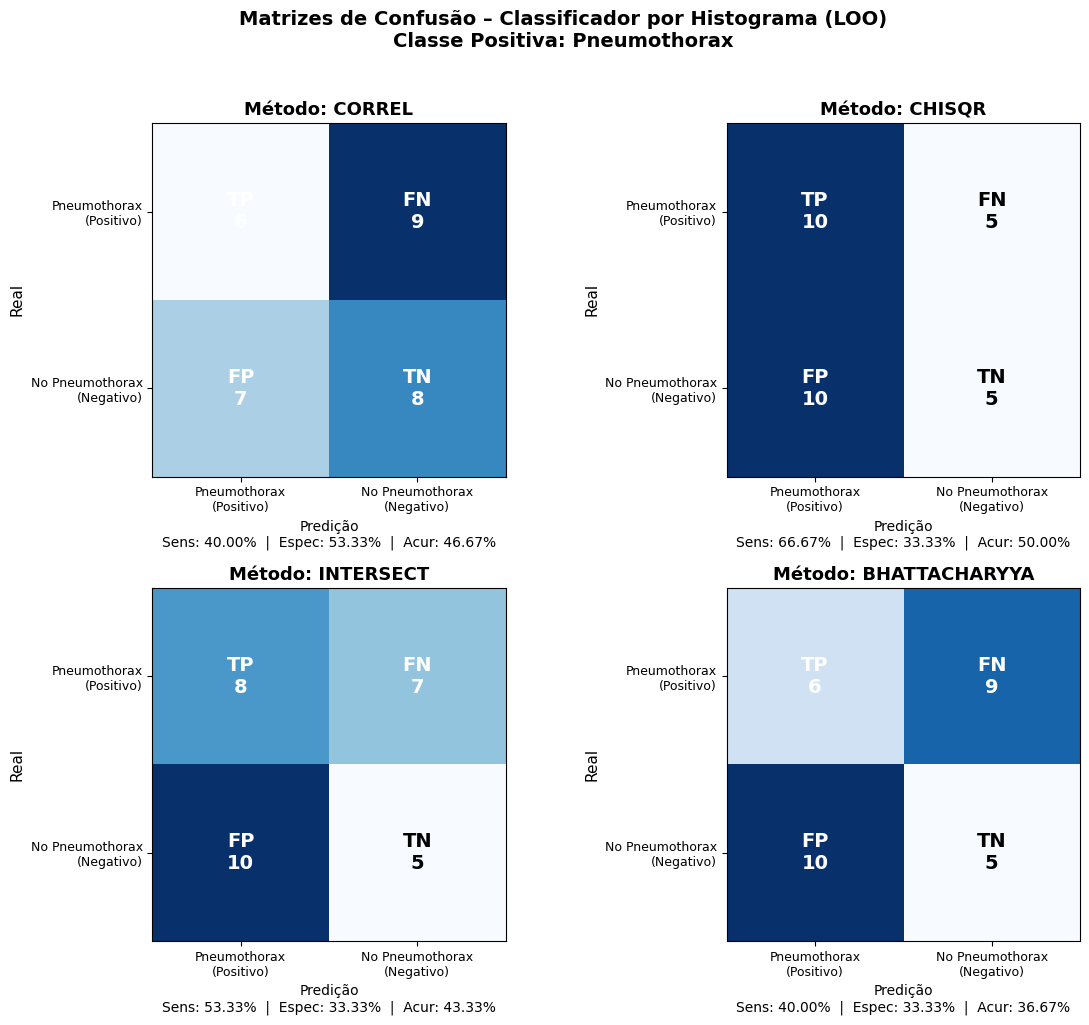

Figura salva em confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

cmap = plt.cm.Blues

for ax, method_name in zip(axes, METHODS.keys()):
    m   = results[method_name]
    cm  = m["confusion_matrix"]

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(f"Método: {method_name}", fontsize=13, fontweight='bold')

    tick_labels = ["Pneumothorax\n(Positivo)", "No Pneumothorax\n(Negativo)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_yticklabels(tick_labels, fontsize=9)
    ax.set_xlabel("Predição", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

    thresh = cm.max() / 2.0
    labels_text = [["TP", "FN"], ["FP", "TN"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels_text[i][j]}\n{cm[i, j]}",
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

    sens = m['sensibilidade']
    spec = m['especificidade']
    acc  = m['acuracia']
    ax.set_xlabel(
        f"Predição\nSens: {sens:.2%}  |  Espec: {spec:.2%}  |  Acur: {acc:.2%}",
        fontsize=10
    )

plt.suptitle("Matrizes de Confusão – Classificador por Histograma (LOO)\nClasse Positiva: Pneumothorax",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figura salva em confusion_matrices.png")

## Tabela Resumo das Métricas

In [ ]:
print("=" * 70)
print(f"{'MÉTODO':<16} {'SENS':>8} {'ESPEC':>8} {'ACUR':>8}  {'TP':>4} {'FN':>4} {'FP':>4} {'TN':>4}")
print("=" * 70)
for method_name, m in results.items():
    print(f"{method_name:<16} "
          f"{m['sensibilidade']:>8.4f} "
          f"{m['especificidade']:>8.4f} "
          f"{m['acuracia']:>8.4f}  "
          f"{m['TP']:>4} {m['FN']:>4} {m['FP']:>4} {m['TN']:>4}")
print("=" * 70)

MÉTODO               SENS    ESPEC     ACUR    TP   FN   FP   TN
CORREL             0.4000   0.5333   0.4667     6    9    7    8
CHISQR             0.6667   0.3333   0.5000    10    5   10    5
INTERSECT          0.5333   0.3333   0.4333     8    7   10    5
BHATTACHARYYA      0.4000   0.3333   0.3667     6    9   10    5


## Exportação dos resultados para .txt

In [ ]:
output_lines = []
output_lines.append("CLASSIFICADOR DE PNEUMOTHORAX")
output_lines.append("=" * 70)
output_lines.append("Classe Positiva: Pneumothorax")
output_lines.append("Classe Negativa: No Pneumothorax")
output_lines.append(f"Total de imagens: {len(labels)} (15 Pneumothorax + 15 No Pneumothorax)")
output_lines.append("")

for method_name, m in results.items():
    output_lines.append("-" * 70)
    output_lines.append(f"MÉTODO: {method_name}")
    output_lines.append("-" * 70)
    output_lines.append("")
    output_lines.append("Matriz de Confusão:")
    output_lines.append("                    Predito Positivo  Predito Negativo")
    output_lines.append(f"  Real Positivo (P)       {m['TP']:>4} (TP)       {m['FN']:>4} (FN)")
    output_lines.append(f"  Real Negativo (N)       {m['FP']:>4} (FP)       {m['TN']:>4} (TN)")
    output_lines.append("")
    output_lines.append(f"  Sensibilidade: {m['sensibilidade']:.4f}  ({m['sensibilidade']:.2%})")
    output_lines.append(f"  Especificidade: {m['especificidade']:.4f}  ({m['especificidade']:.2%})")
    output_lines.append(f"  Acurácia:   {m['acuracia']:.4f}  ({m['acuracia']:.2%})")
    output_lines.append("")

output_lines.append("=" * 70)
output_lines.append("RESUMO COMPARATIVO")
output_lines.append("=" * 70)
output_lines.append(f"{'Método':<16} {'Sens':>8} {'Espec':>8} {'Acur':>8}  {'TP':>4} {'FN':>4} {'FP':>4} {'TN':>4}")
output_lines.append("-" * 70)
for method_name, m in results.items():
    output_lines.append(
        f"{method_name:<16} "
        f"{m['sensibilidade']:>8.4f} "
        f"{m['especificidade']:>8.4f} "
        f"{m['acuracia']:>8.4f}  "
        f"{m['TP']:>4} {m['FN']:>4} {m['FP']:>4} {m['TN']:>4}"
    )

output_text = "\n".join(output_lines)
print(output_text)

with open("resultados.txt", "w", encoding="utf-8") as f:
    f.write(output_text)

print("\nArquivo 'resultados.txt' salvo com sucesso.")

CLASSIFICADOR DE PNEUMOTHORAX
Classe Positiva: Pneumothorax
Classe Negativa: No Pneumothorax
Total de imagens: 30 (15 Pneumothorax + 15 No Pneumothorax)

----------------------------------------------------------------------
MÉTODO: CORREL
----------------------------------------------------------------------

Matriz de Confusão:
                    Predito Positivo  Predito Negativo
  Real Positivo (P)          6 (TP)          9 (FN)
  Real Negativo (N)          7 (FP)          8 (TN)

  Sensibilidade: 0.4000  (40.00%)
  Especificidade: 0.5333  (53.33%)
  Acurácia:   0.4667  (46.67%)

----------------------------------------------------------------------
MÉTODO: CHISQR
----------------------------------------------------------------------

Matriz de Confusão:
                    Predito Positivo  Predito Negativo
  Real Positivo (P)         10 (TP)          5 (FN)
  Real Negativo (N)         10 (FP)          5 (TN)

  Sensibilidade: 0.6667  (66.67%)
  Especificidade: 0.3333  (33.33%)
